In [1]:
import duckdb

con = duckdb.connect("ipeds.duckdb")

query = """
SELECT 
    s.unitid,
    s.year,
    h.institution_name,
    h.city,
    h.state,
    s.arank,
    CASE 
        WHEN s.arank = 1 THEN 'Full'
        WHEN s.arank = 2 THEN 'Associate'
        WHEN s.arank = 3 THEN 'Assistant'
    END AS rank,
    s.saeq9at,
    s.satotlt,
    s.saoutlt,
    s.sa09mct, s.sa10mct, s.sa11mct, s.sa12mct,
    s.sa09mat, s.sa10mat, s.sa11mat, s.sa12mat

FROM sal_is s
LEFT JOIN hd h 
    ON s.unitid = h.unitid 
   AND s.year = h.year

WHERE s.arank IN (1, 2, 3)
"""

df = con.sql(query).df()

print(df.shape)
df.head()



(94011, 18)


,unitid,year,institution_name,city,state,arank,rank,saeq9at,satotlt,saoutlt,sa09mct,sa10mct,sa11mct,sa12mct,sa09mat,sa10mat,sa11mat,sa12mat
0,100654,2024,Alabama A & M University,Normal,AL,3,Assistant,74640.0,107,8029607,104.0,0.0,0.0,3.0,75551.0,NaN,NaN,57449.0
1,100663,2024,University of Alabama at Birmingham,Birmingham,AL,3,Assistant,88941.0,334,35555364,138.0,0.0,0.0,196.0,88112.0,NaN,NaN,119367.0
2,100690,2024,Amridge University,Montgomery,AL,3,Assistant,50340.0,5,329198,0.0,1.0,0.0,4.0,NaN,32000.0,NaN,74300.0
3,100706,2024,University of Alabama in Huntsville,Huntsville,AL,3,Assistant,90664.0,110,10031338,108.0,0.0,0.0,2.0,90725.0,NaN,NaN,116505.0
4,100724,2024,Alabama State University,Montgomery,AL,3,Assistant,67619.0,64,4808469,0.0,64.0,0.0,0.0,NaN,75132.0,NaN,NaN


In [2]:


# UPG UNITIDs + Siena 195474
upg_unitids = [195474,
               215929, 216278, 167996, 218070, 163046, 123554,
               203368, 209825, 213251, 110413, 214175, 214157,
               209056, 152390, 150163, 217536, 184348, 136950,
               164562, 193584, 221519, 165699, 213507, 195216,
               212197, 215770, 236230, 183239, 239716, 146481,
               134079, 237066, 224323, 191968, 221351, 230816]

# 6. Create UPG

upg = df[df['unitid'].isin(upg_unitids)].copy()

print('Dataframe \t Rows \t Columns')
print('df         \t', df.shape[0], '\t', df.shape[1])
print('upg        \t', upg.shape[0], '\t', upg.shape[1])

upg



Dataframe 	 Rows 	 Columns
df         	 94011 	 18
upg        	 1404 	 18


,unitid,year,institution_name,city,state,arank,rank,saeq9at,satotlt,saoutlt,sa09mct,sa10mct,sa11mct,sa12mct,sa09mat,sa10mat,sa11mat,sa12mat
86,110413,2024,California Lutheran University,Thousand Oaks,CA,3,Assistant,83318.0,28,2332909,28.0,0.0,0.0,0.0,83318.0,NaN,NaN,NaN
187,123554,2024,Saint Mary's College of California,Moraga,CA,3,Assistant,87914.0,43,3780312,43.0,0.0,0.0,0.0,87914.0,NaN,NaN,NaN
293,134079,2024,Florida Southern College,Lakeland,FL,3,Assistant,76153.0,61,4828534,53.0,1.0,0.0,7.0,76313.0,85381.0,NaN,99794.0
315,136950,2024,Rollins College,Winter Park,FL,3,Assistant,78902.0,26,2070511,25.0,0.0,0.0,1.0,79770.0,NaN,NaN,76267.0
462,146481,2024,Lake Forest College,Lake Forest,IL,3,Assistant,67545.0,41,2769356,41.0,0.0,0.0,0.0,67545.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93266,221519,2012,Sewanee-The University of the South,Sewanee,TN,1,Full,NaN,68,6427883,68.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
93300,224323,2012,University of Dallas,Irving,TX,1,Full,NaN,24,1837442,24.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
93487,236230,2012,Pacific Lutheran University,Tacoma,WA,1,Full,NaN,54,4473735,51.0,2.0,0.0,1.0,NaN,NaN,NaN,NaN
93498,237066,2012,Whitworth University,Spokane,WA,1,Full,NaN,40,3315409,36.0,2.0,1.0,1.0,NaN,NaN,NaN,NaN


In [14]:
sa = upg.fillna(0).copy()
sa['avgsal'] = (sa['sa09mat']*sa['sa09mct'] + 
                 sa['sa10mat']*sa['sa10mct'] + 
                 sa['sa11mat']*sa['sa11mct'] + 
                 sa['sa12mat']*sa['sa12mct']) / (sa['sa09mct'] + sa['sa10mct'] + sa['sa11mct'] + sa['sa12mct'])
sa['argave'] = sa['saoutlt'] / sa['satotlt']
sa

,unitid,year,institution_name,city,state,arank,rank,saeq9at,satotlt,saoutlt,sa09mct,sa10mct,sa11mct,sa12mct,sa09mat,sa10mat,sa11mat,sa12mat,avgsal,argave
86,110413,2024,California Lutheran University,Thousand Oaks,CA,3,Assistant,83318.0,28,2332909,28.0,0.0,0.0,0.0,83318.0,0.0,0.0,0.0,83318.000000,83318.178571
187,123554,2024,Saint Mary's College of California,Moraga,CA,3,Assistant,87914.0,43,3780312,43.0,0.0,0.0,0.0,87914.0,0.0,0.0,0.0,87914.000000,87914.232558
293,134079,2024,Florida Southern College,Lakeland,FL,3,Assistant,76153.0,61,4828534,53.0,1.0,0.0,7.0,76313.0,85381.0,0.0,99794.0,79156.196721,79156.295082
315,136950,2024,Rollins College,Winter Park,FL,3,Assistant,78902.0,26,2070511,25.0,0.0,0.0,1.0,79770.0,0.0,0.0,76267.0,79635.269231,79635.038462
462,146481,2024,Lake Forest College,Lake Forest,IL,3,Assistant,67545.0,41,2769356,41.0,0.0,0.0,0.0,67545.0,0.0,0.0,0.0,67545.000000,67545.268293
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93266,221519,2012,Sewanee-The University of the South,Sewanee,TN,1,Full,0.0,68,6427883,68.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,94527.691176
93300,224323,2012,University of Dallas,Irving,TX,1,Full,0.0,24,1837442,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,76560.083333
93487,236230,2012,Pacific Lutheran University,Tacoma,WA,1,Full,0.0,54,4473735,51.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.000000,82846.944444
93498,237066,2012,Whitworth University,Spokane,WA,1,Full,0.0,40,3315409,36.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,0.000000,82885.225000


In [16]:
full_avg = (
    sa[sa['rank'] == 'Full']
    .groupby(['unitid'], as_index=False)['argave']
    .mean()
    .rename(columns={'argave': 'average_salary'})
)

# Add institution name from year 2024
names_2024 = (
    sa[['unitid', 'institution_name','year']]
    .query('year == 2024')
    .drop_duplicates(subset=['unitid'])          # in case of any duplicates
)

full_avg = full_avg.merge(
    names_2024, 
    on='unitid', 
    how='left'
)

# Final sorting
full_avg = (
    full_avg
    .sort_values('average_salary', ascending=False)
    .reset_index(drop=True)    
)

full_avg

,unitid,average_salary,institution_name,year
0,163046,127456.780728,Loyola University Maryland,2024
1,209056,123324.856353,Lewis & Clark College,2024
2,215770,121335.709483,Saint Joseph's University - Philadelphia,2024
3,110413,115558.639665,California Lutheran University,2024
4,215929,113807.326159,University of Scranton,2024
5,123554,112233.058342,Saint Mary's College of California,2024
6,195216,111203.515369,St Lawrence University,2024
7,167996,109327.397568,Stonehill College,2024
8,221519,107495.573237,The University of the South,2024
9,165699,105003.146866,Endicott College,2024


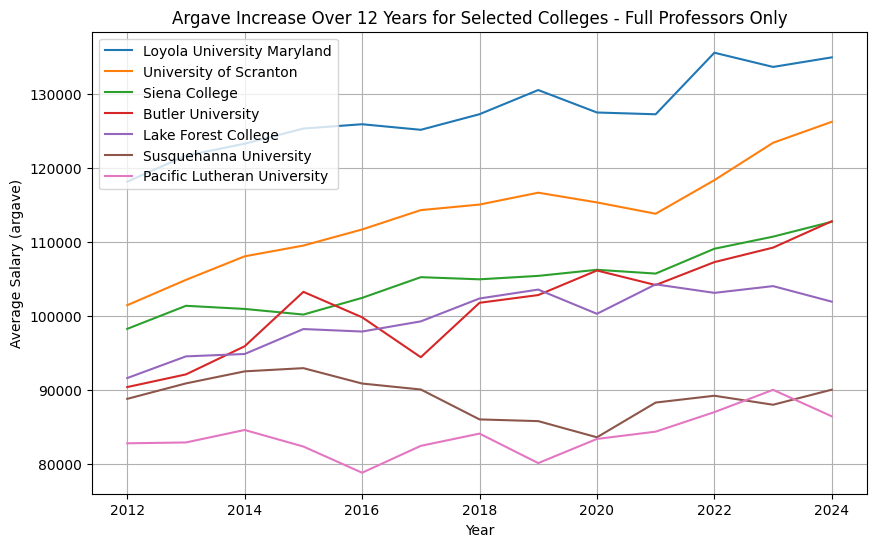

In [ ]:
filtered_full = sa[
    (sa['unitid'].isin(selected_unitids)) &
    (sa['rank'] == 'Full')
]

plt.figure(figsize=(10, 6))
_ax = plt.gca()
plt.legend = lambda *args, **kwargs: _ax.legend(
    *args, bbox_to_anchor=(1.05, 1), loc='upper left', **kwargs
)

for uid in selected_unitids:
    data = filtered_full[filtered_full['unitid'] == uid].sort_values('year')
    if data.empty:
        continue
    plt.plot(data['year'], data['argave'], label=data['institution_name'].iloc[0])

plt.xlabel('Year')
plt.ylabel('Average Salary (argave)')
plt.title('Argave Increase Over 12 Years for Selected Colleges - Full Professors Only')
plt.legend()
plt.grid(True)
plt.show()